# L42 — Bridge Card HCP Classifier
### ResNet-50 Transfer Learning on Google Colab (Free T4 GPU)

**Research Question:** Can ResNet-50 accurately classify bridge playing cards by HCP (High Card Points)?

**HCP Rules:** Ace=4 pts, King=3 pts, Queen=2 pts, Jack=1 pt, all other cards=0 pts

---
**Before running:**
1. Go to **Runtime → Change runtime type → T4 GPU**
2. Run all cells top to bottom
3. In Cell 2, upload your `kaggle.json` file when prompted

In [1]:
# Cell 1 — Install dependencies
!pip install -q kagglehub seaborn scikit-learn

In [2]:
# Cell 2 — Kaggle authentication
# Upload your kaggle.json when the file picker opens.
# To get kaggle.json: kaggle.com -> Settings -> API -> Create New Token
import os
import json
from google.colab import userdata

os.makedirs('/root/.config/kaggle', exist_ok=True)
with open('/root/.config/kaggle/kaggle.json', 'w') as f:
    json.dump({
        "username": userdata.get('KAGGLE_USERNAME'),
        "key": userdata.get('KAGGLE_KEY')
    }, f)
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print("Kaggle credentials saved.")

Kaggle credentials saved.


In [3]:
# Cell 3 — Imports
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import kagglehub

print(f"TensorFlow version : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available     : {len(gpus)}")
if gpus:
    print(f"GPU name           : {gpus[0].name}")

TensorFlow version : 2.19.0
GPUs available     : 1
GPU name           : /physical_device:GPU:0


In [4]:
# Cell 4 — Configuration  (equivalent to config.py)
OUTPUT_DIR              = "/content/outputs"
MODEL_PATH              = os.path.join(OUTPUT_DIR, "resnet50_hcp_model.keras")
HISTORY_PLOT            = os.path.join(OUTPUT_DIR, "training_history.png")
CONFUSION_MATRIX_PLOT   = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
SAMPLE_PREDICTIONS_PLOT = os.path.join(OUTPUT_DIR, "sample_predictions.png")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Full-quality run — Colab T4 GPU handles this easily
IMAGE_SIZE           = (224, 224)
BATCH_SIZE           = 32
EPOCHS               = 20   # Phase 1: frozen backbone
LEARNING_RATE        = 1e-4
FINE_TUNE_EPOCHS     = 20   # Phase 2: unfrozen top layers (increased from 10)
FINE_TUNE_LR         = 1e-6
MAX_IMAGES_PER_CLASS = None  # load all images
NUM_CLASSES          = 5

HCP_CLASSES = {
    0: "0 pts  (2-10)",
    1: "J = 1 pt",
    2: "Q = 2 pts",
    3: "K = 3 pts",
    4: "A = 4 pts",
}

RANK_TO_HCP = {
    "ace":   4,
    "king":  3,
    "queen": 2,
    "jack":  1,
}

CLASS_COLORS = ["#4472C4", "#ED7D31", "#70AD47", "#FFC000", "#E63946"]
LABELS       = list(HCP_CLASSES.values())

print("Config loaded. IMAGE_SIZE:", IMAGE_SIZE, "| EPOCHS:", EPOCHS)

Config loaded. IMAGE_SIZE: (224, 224) | EPOCHS: 20


In [5]:
# Cell 5 — Download dataset  (equivalent to dataset.py)
print("Downloading Cards Image Dataset from Kaggle...")
dataset_root = kagglehub.dataset_download(
    "gpiosenka/cards-image-datasetclassification"
)
print(f"Dataset ready at: {dataset_root}")

# Show folder structure
splits = [d for d in os.listdir(dataset_root)
          if os.path.isdir(os.path.join(dataset_root, d))]
print("Splits found:", splits)

Using Colab cache for faster access to the 'cards-image-datasetclassification' dataset.
Dataset ready at: /kaggle/input/cards-image-datasetclassification
Splits found: ['valid', 'test', 'train']


In [6]:
# Cell 6 — Data loading functions  (equivalent to dataset.py)
def folder_to_hcp(folder_name: str) -> int:
    """Map folder name like 'king of hearts' to HCP value (0-4)."""
    name = folder_name.lower()
    for rank, hcp in RANK_TO_HCP.items():
        if rank in name:
            return hcp
    return 0


def load_split(split_dir: str):
    """Load all images from one dataset split. Returns X (float32), y (one-hot)."""
    images, labels = [], []
    folders = sorted(
        d for d in os.listdir(split_dir)
        if os.path.isdir(os.path.join(split_dir, d))
    )
    for folder in folders:
        hcp   = folder_to_hcp(folder)
        fpath = os.path.join(split_dir, folder)
        all_files = [
            f for f in os.listdir(fpath)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        if MAX_IMAGES_PER_CLASS is not None:
            all_files = all_files[:MAX_IMAGES_PER_CLASS]
        for fname in all_files:
            img = tf.keras.utils.load_img(
                os.path.join(fpath, fname), target_size=IMAGE_SIZE
            )
            images.append(tf.keras.utils.img_to_array(img) / 255.0)
            labels.append(hcp)

    X = np.array(images, dtype="float32")
    y = tf.keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)
    print(f"  [{split_dir.split(os.sep)[-1]:5s}] {len(X):5d} images loaded")
    return X, y


def get_data_generators(root: str):
    """Build train generator + validation/test arrays."""
    print("\nLoading dataset splits...")
    X_tr, y_tr = load_split(os.path.join(root, "train"))
    X_va, y_va = load_split(os.path.join(root, "valid"))
    X_te, y_te = load_split(os.path.join(root, "test"))

    print("\nHCP class distribution in TRAIN set:")
    raw_labels = np.argmax(y_tr, axis=1)
    for cls, name in HCP_CLASSES.items():
        count = int((raw_labels == cls).sum())
        print(f"  Class {cls} | {name:14s} | {count:4d} images")

    aug = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.10,
        height_shift_range=0.10,
        horizontal_flip=True,
        zoom_range=0.10,
        brightness_range=[0.85, 1.15],
    )
    train_gen = aug.flow(X_tr, y_tr, batch_size=BATCH_SIZE, shuffle=True)
    return train_gen, (X_va, y_va), (X_te, y_te)


print("Data functions defined.")

Data functions defined.


In [7]:
# Cell 7 — Load all data + compute class weights
from sklearn.utils.class_weight import compute_class_weight

train_gen, val_data, test_data = get_data_generators(dataset_root)

# Compute class weights to fix class imbalance
# (class 0 has ~9x more images than J/Q/K/A)
raw_labels = np.argmax(train_gen.y, axis=1)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=raw_labels,
)
class_weights = dict(enumerate(class_weights_array))

print("\nClass weights (higher = model pays more attention):")
for cls, w in class_weights.items():
    print(f"  Class {cls} | {HCP_CLASSES[cls]:14s} | weight = {w:.3f}")


Loading dataset splits...
  [train]  7624 images loaded
  [valid]   265 images loaded
  [test ]   265 images loaded

HCP class distribution in TRAIN set:
  Class 0 | 0 pts  (2-10)  | 5188 images
  Class 1 | J = 1 pt       |  671 images
  Class 2 | Q = 2 pts      |  625 images
  Class 3 | K = 3 pts      |  539 images
  Class 4 | A = 4 pts      |  601 images

Class weights (higher = model pays more attention):
  Class 0 | 0 pts  (2-10)  | weight = 0.294
  Class 1 | J = 1 pt       | weight = 2.272
  Class 2 | Q = 2 pts      | weight = 2.440
  Class 3 | K = 3 pts      | weight = 2.829
  Class 4 | A = 4 pts      | weight = 2.537


In [8]:
# Cell 8 — Model definition  (equivalent to model.py)
def build_model(trainable_backbone: bool = False) -> Model:
    """Build and compile ResNet-50 HCP classifier."""
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMAGE_SIZE, 3)
    )
    base.trainable = trainable_backbone

    inputs  = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(512, activation="relu")(x)
    x       = layers.Dropout(0.40)(x)
    x       = layers.Dense(256, activation="relu")(x)
    x       = layers.Dropout(0.30)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs, outputs, name="ResNet50_HCP")
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def unfreeze_top_layers(model: Model, n_layers: int = 10) -> Model:
    """Unfreeze top n_layers of ResNet-50 for fine-tuning."""
    base = model.layers[1]
    base.trainable = True
    for layer in base.layers[:-n_layers]:
        layer.trainable = False
    model.compile(
        optimizer=Adam(learning_rate=FINE_TUNE_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def get_callbacks() -> list:
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=8,   # increased from 5
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=MODEL_PATH, monitor="val_accuracy",
            save_best_only=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=3, min_lr=1e-8, verbose=1,
        ),
    ]


print("Model functions defined.")

Model functions defined.


In [9]:
# Cell 9 — Phase 1: Train head with FROZEN backbone
print("=" * 55)
print("  PHASE 1 — Training head  (backbone frozen)")
print("=" * 55)

model = build_model(trainable_backbone=False)

trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
total     = sum(tf.size(v).numpy() for v in model.variables)
print(f"  Params: {trainable:,} trainable / {total:,} total\n")

history1 = model.fit(
    train_gen,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=get_callbacks(),
    class_weight=class_weights,   # fix class imbalance
    verbose=1,
)

  PHASE 1 — Training head  (backbone frozen)
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Params: 1,181,701 trainable / 24,769,417 total



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.2256 - loss: 1.6848
Epoch 1: val_accuracy improved from -inf to 0.57358, saving model to /content/outputs/resnet50_hcp_model.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 135s 498ms/step - accuracy: 0.2256 - loss: 1.6849 - val_accuracy: 0.5736 - val_loss: 1.4555 - learning_rate: 1.0000e-04
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.2184 - loss: 1.6306
Epoch 2: val_accuracy improved from 0.57358 to 0.64528, saving model to /content/outputs/resnet50_hcp_model.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 103s 431ms/step - accuracy: 0.2184 - loss: 1.6305 - val_accuracy: 0.6453 - val_loss: 1.5019 - learning_rate: 1.0000e-04
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.2412 - loss: 1.6139
Epoch 3: val_accuracy did not improve from 0.64528
239/239 ━━━━━━━━━━━━━━━━━━━━ 100s 417ms/step - accuracy: 0.2412 - loss: 1.6138 - val_accuracy: 0.6340 - val_loss: 1.5531 - learning_rate: 1.0000e-04
Epoch 4/20
23

In [10]:
# Cell 10 — Phase 2: Fine-tune top 30 ResNet layers
print("=" * 55)
print("  PHASE 2 — Fine-tuning  (top 30 layers unfrozen)")
print("=" * 55)

model = unfreeze_top_layers(model, n_layers=30)

history2 = model.fit(
    train_gen,
    validation_data=val_data,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=get_callbacks(),
    class_weight=class_weights,   # fix class imbalance
    verbose=1,
)

  PHASE 2 — Fine-tuning  (top 30 layers unfrozen)
Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.6589 - loss: 3.2174
Epoch 1: val_accuracy improved from -inf to 0.69811, saving model to /content/outputs/resnet50_hcp_model.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 142s 500ms/step - accuracy: 0.6588 - loss: 3.2142 - val_accuracy: 0.6981 - val_loss: 2.1351 - learning_rate: 1.0000e-06
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.4777 - loss: 1.7800
Epoch 2: val_accuracy did not improve from 0.69811
239/239 ━━━━━━━━━━━━━━━━━━━━ 104s 437ms/step - accuracy: 0.4775 - loss: 1.7797 - val_accuracy: 0.6981 - val_loss: 1.6908 - learning_rate: 1.0000e-06
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.3352 - loss: 1.6576
Epoch 3: val_accuracy did not improve from 0.69811
239/239 ━━━━━━━━━━━━━━━━━━━━ 105s 438ms/step - accuracy: 0.3351 - loss: 1.6575 - val_accuracy: 0.6491 - val_loss: 1.5523 - learning_rate: 1.0000e-06
Epoch 4/20
239/239 ━━━━━━━

In [11]:
# Cell 11 — Evaluate on test set
X_test, y_test = test_data
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("=" * 55)
print("  TEST SET RESULTS")
print(f"  Accuracy : {acc * 100:.2f}%")
print(f"  Loss     : {loss:.4f}")
print("=" * 55)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

threshold = 0.80
verdict   = "CAN" if acc >= threshold else "STRUGGLES TO"
print(f"\n  Research Question: 'Can ResNet-50 classify cards by HCP?'")
print(f"  The model {verdict} do this accurately.")
print(f"  (Test accuracy = {acc * 100:.2f}%  |  threshold = 80%)\n")

  TEST SET RESULTS
  Accuracy : 69.81%
  Loss     : 2.0619

  Research Question: 'Can ResNet-50 classify cards by HCP?'
  The model STRUGGLES TO do this accurately.
  (Test accuracy = 69.81%  |  threshold = 80%)



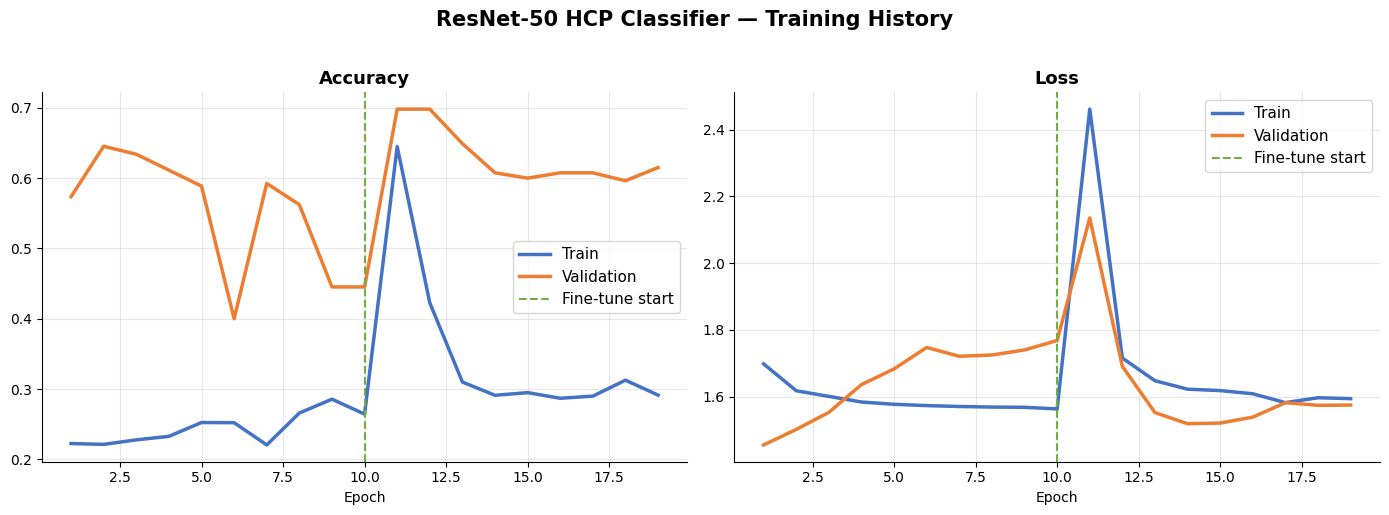

Saved: /content/outputs/training_history.png


In [12]:
# Cell 12 — Visualization: Training history
acc_all  = history1.history["accuracy"]     + history2.history["accuracy"]
vacc_all = history1.history["val_accuracy"] + history2.history["val_accuracy"]
loss_all = history1.history["loss"]         + history2.history["loss"]
vloss_all= history1.history["val_loss"]     + history2.history["val_loss"]
ep       = range(1, len(acc_all) + 1)
split    = len(history1.history["accuracy"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ResNet-50 HCP Classifier — Training History",
             fontsize=15, fontweight="bold", y=1.02)

for ax, (train_m, val_m), title in [
    (ax1, (acc_all,  vacc_all),  "Accuracy"),
    (ax2, (loss_all, vloss_all), "Loss"),
]:
    ax.plot(ep, train_m, color="#4472C4", lw=2.5, label="Train")
    ax.plot(ep, val_m,   color="#ED7D31", lw=2.5, label="Validation")
    ax.axvline(split, color="#70AD47", lw=1.5, linestyle="--", label="Fine-tune start")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(HISTORY_PLOT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {HISTORY_PLOT}")

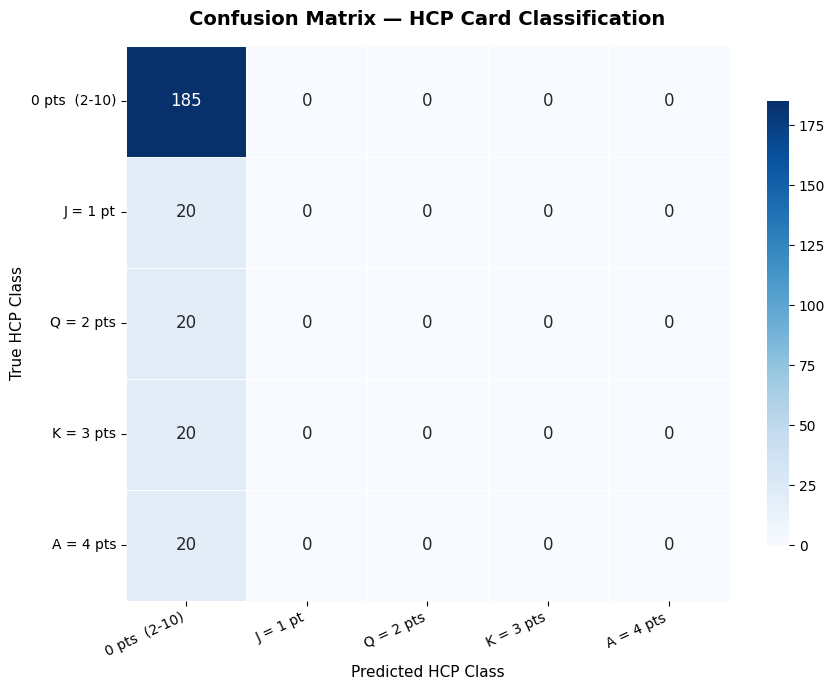

Saved: /content/outputs/confusion_matrix.png


In [13]:
# Cell 13 — Visualization: Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS,
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 12})
ax.set_title("Confusion Matrix — HCP Card Classification",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Predicted HCP Class", fontsize=11)
ax.set_ylabel("True HCP Class",      fontsize=11)
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PLOT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {CONFUSION_MATRIX_PLOT}")

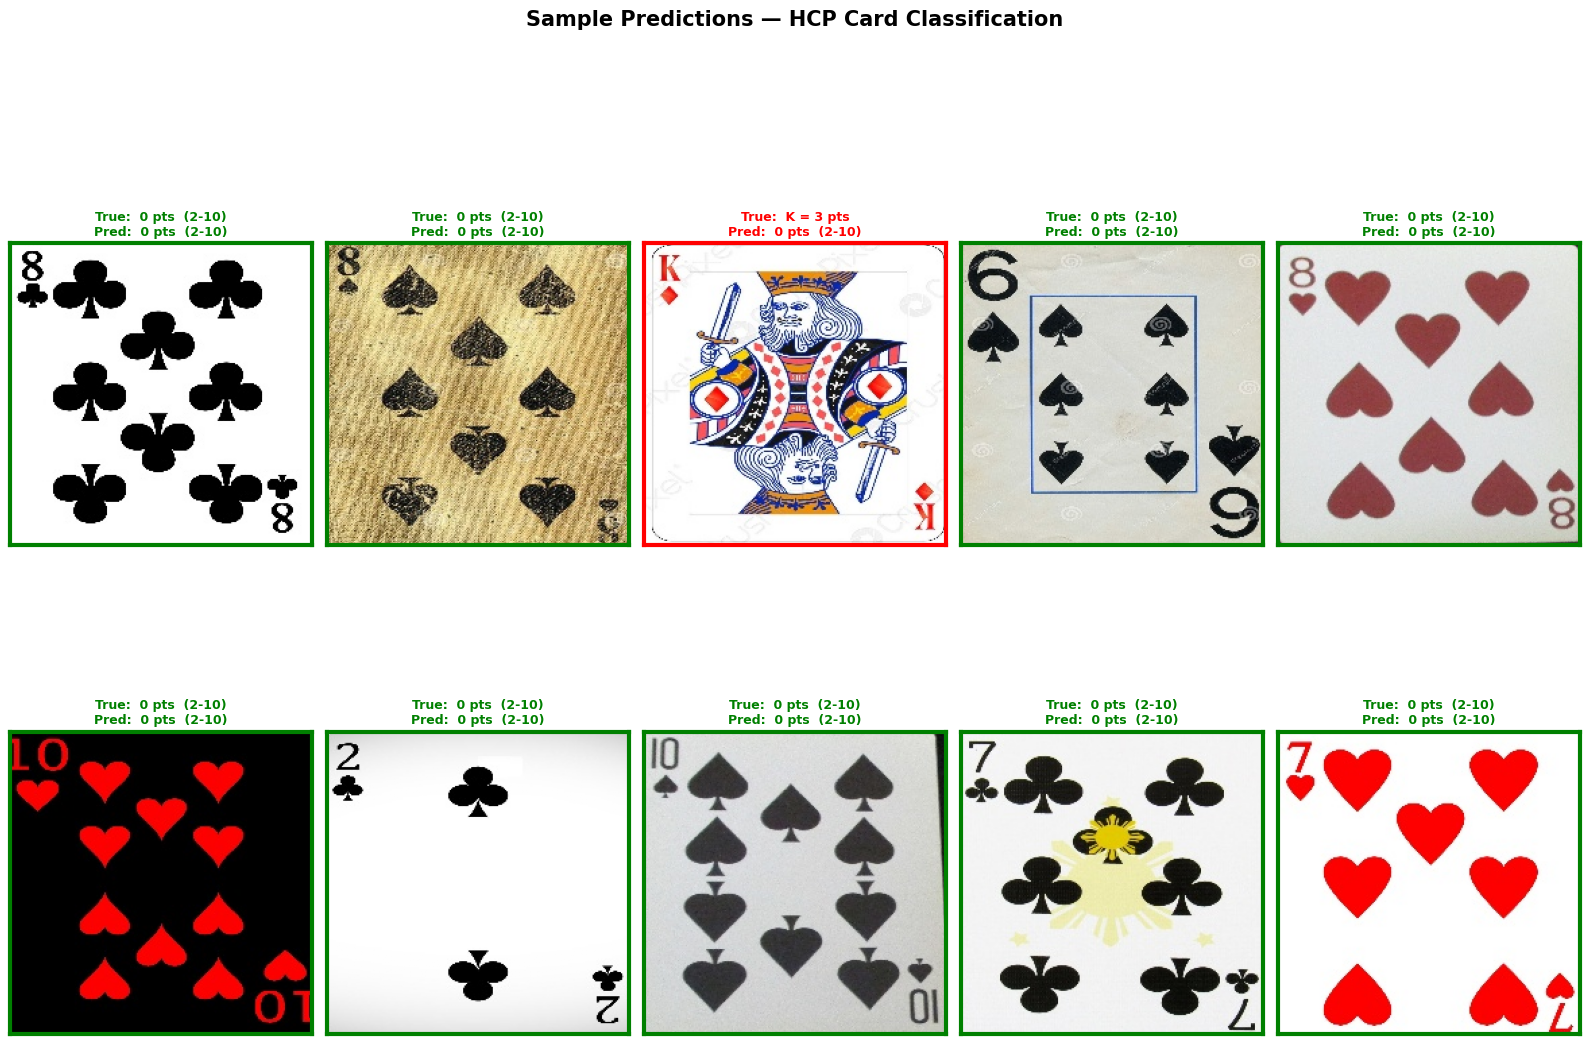

Saved: /content/outputs/sample_predictions.png


In [14]:
# Cell 14 — Visualization: Sample predictions
n     = 10
idxs  = np.random.choice(len(X_test), n, replace=False)
preds = np.argmax(model.predict(X_test[idxs], verbose=0), axis=1)
cols  = 5
rows  = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
fig.suptitle("Sample Predictions — HCP Card Classification",
             fontsize=15, fontweight="bold", y=1.01)

for ax, idx, pred in zip(axes.flat, idxs, preds):
    true = int(y_true[idx])
    ok   = pred == true
    ax.imshow(X_test[idx])
    ax.set_title(
        f"True:  {LABELS[true]}\nPred:  {LABELS[pred]}",
        color="green" if ok else "red", fontsize=9, fontweight="bold"
    )
    for spine in ax.spines.values():
        spine.set_edgecolor("green" if ok else "red")
        spine.set_linewidth(3)
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(SAMPLE_PREDICTIONS_PLOT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {SAMPLE_PREDICTIONS_PLOT}")

In [15]:
# Cell 15 — Per-class classification report
print("=" * 55)
print("  PER-CLASS CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_true, y_pred, target_names=LABELS))

  PER-CLASS CLASSIFICATION REPORT
               precision    recall  f1-score   support

0 pts  (2-10)       0.70      1.00      0.82       185
     J = 1 pt       0.00      0.00      0.00        20
    Q = 2 pts       0.00      0.00      0.00        20
    K = 3 pts       0.00      0.00      0.00        20
    A = 4 pts       0.00      0.00      0.00        20

     accuracy                           0.70       265
    macro avg       0.14      0.20      0.16       265
 weighted avg       0.49      0.70      0.57       265



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
# Cell 16 — Download all outputs to your computer
from google.colab import files
import zipfile

zip_path = "/content/L42_outputs.zip"
with zipfile.ZipFile(zip_path, 'w') as zf:
    for fname in ["training_history.png", "confusion_matrix.png",
                  "sample_predictions.png", "resnet50_hcp_model.keras"]:
        fpath = os.path.join(OUTPUT_DIR, fname)
        if os.path.exists(fpath):
            zf.write(fpath, fname)
            print(f"Added: {fname}")

print("\nDownloading L42_outputs.zip ...")
files.download(zip_path)

Added: training_history.png
Added: confusion_matrix.png
Added: sample_predictions.png
Added: resnet50_hcp_model.keras



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>